<a href="https://colab.research.google.com/github/solankiboy939/Deep_Learning/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports necessary libraries for building and training a neural network with TensorFlow and Keras. It includes modules for loading the MNIST dataset, preparing data (like one-hot encoding), defining model layers (commented out in this version), and numerical operations with NumPy.

In [43]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, Flatten
# from tensorflow.keras.layers import Conv2D, MaxPooling2D
import numpy as np

This cell loads the MNIST dataset, which consists of grayscale images of handwritten digits (0-9) and their corresponding labels. The dataset is split into training and testing sets.

In [45]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [46]:
train_images_resized = tf.image.resize(train_images, [32, 32])
test_images_resized = tf.image.resize(test_images, [32, 32])

# Convert grayscale to RGB by stacking the channel 3 times
train_images_rgb = np.stack([train_images_resized]*3, axis = -1)/255.0
test_images_rgb = np.stack([test_images_resized]*3, axis = -1)/255.0


train_labels_one_hot = to_categorical(train_labels)
test_labels_one_hot = to_categorical(test_labels)

print("Shape of train_images_rgb:", train_images_rgb.shape)
print("Shape of train_labels_one_hot:", train_labels_one_hot.shape)
print("Shape of test_images_rgb:", test_images_rgb.shape)
print("Shape of test_labels_one_hot:", test_labels_one_hot.shape)

Shape of train_images_rgb: (32, 32, 28, 3)
Shape of train_labels_one_hot: (60000, 10)
Shape of test_images_rgb: (32, 32, 28, 3)
Shape of test_labels_one_hot: (10000, 10)


This cell fine-tunes the pre-trained MobileNetV2 model. It unfreezes the entire base model and then selectively freezes the first 100 layers to allow training on the later layers. The model is recompiled with the Adam optimizer and trained for another 3 epochs with a validation split of 0.2. This step allows the model to adapt better to the specific MNIST dataset while still leveraging the learned features from the ImageNet dataset.

In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

In [48]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False    #Freeze base model
inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

/tmp/ipython-input-3048743512.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


In [52]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images_rgb, train_labels_one_hot, epochs = 3, validation_split = 0.2)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.7094 - loss: 0.8409 - val_accuracy: 0.7224 - val_loss: 0.7996
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.7255 - loss: 0.7910 - val_accuracy: 0.7285 - val_loss: 0.7831
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 133s 57ms/step - accuracy: 0.7386 - loss: 0.7580 - val_accuracy: 0.7377 - val_loss: 0.7612


In [53]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images_rgb, train_labels_one_hot, epochs = 3, validation_split = 0.2)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 232s 145ms/step - accuracy: 0.7523 - loss: 1.8861 - val_accuracy: 0.5700 - val_loss: 1.3898
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 208s 139ms/step - accuracy: 0.9176 - loss: 0.2870 - val_accuracy: 0.8112 - val_loss: 0.5948
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 267s 142ms/step - accuracy: 0.9370 - loss: 0.2314 - val_accuracy: 0.9428 - val_loss: 0.2104


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


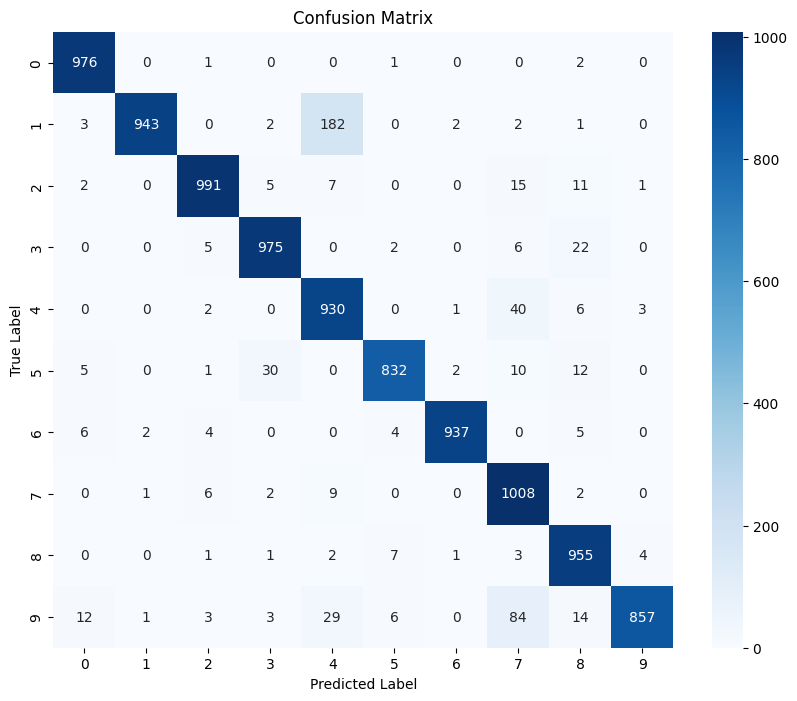

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the model
predictions = model.predict(test_images_rgb)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels_one_hot, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()